In [1]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.inspection import permutation_importance
import seaborn as sns
from scipy.stats import norm
import statsmodels.api as sm
import pandas as pd
from sklearn.manifold import MDS
import numpy as np
import os
directory = os.getcwd()
parent_directory = os.path.dirname(directory)
%load_ext rpy2.ipython

# Correlation between experiments of best layer

In [2]:
df_layers_exp1 = pd.read_csv('1_quadrilaterals/df_layers.csv')
df_layers_exp2 = pd.read_csv('2_shape_LoT/best_layers.csv')
df_layers_exp3 = pd.read_csv('3_abstract_drawings/best_layers.csv')

In [3]:
# Merge the two dataframes on model
merged = pd.merge(df_layers_exp1[['model', 'best_layer']], 
                  df_layers_exp2[['model', 'best_layer']], 
                  on='model', 
                  suffixes=('_df1', '_df2'))

# Count matches
n_total = len(merged)
n_matches = (merged['best_layer_df1'] == merged['best_layer_df2']).sum()

proportion = n_matches / n_total if n_total > 0 else float('nan')

print(f"Proportion of models with same best layer: {proportion:.3f}")

Proportion of models with same best layer: 0.533


In [4]:
# Merge the two dataframes on model
merged = pd.merge(df_layers_exp1[['model', 'best_layer']], 
                  df_layers_exp3[['model', 'best_layer']], 
                  on='model', 
                  suffixes=('_df1', '_df2'))

# Count matches
n_total = len(merged)
n_matches = (merged['best_layer_df1'] == merged['best_layer_df2']).sum()

proportion = n_matches / n_total if n_total > 0 else float('nan')

print(f"Proportion of models with same best layer: {proportion:.3f}")

Proportion of models with same best layer: 0.326


In [5]:
# Merge the two dataframes on model
merged = pd.merge(df_layers_exp2[['model', 'best_layer']], 
                  df_layers_exp3[['model', 'best_layer']], 
                  on='model', 
                  suffixes=('_df1', '_df2'))

# Count matches
n_total = len(merged)
n_matches = (merged['best_layer_df1'] == merged['best_layer_df2']).sum()

proportion = n_matches / n_total if n_total > 0 else float('nan')

print(f"Proportion of models with same best layer: {proportion:.3f}")

Proportion of models with same best layer: 0.558


# Representing the networks in 2D according to performance in the different experiments

In [9]:
df1 = pd.read_csv('1_quadrilaterals/all_cors.csv')
df2 = pd.read_csv('2_shape_LoT/all_cors.csv')
df3 = pd.read_csv('3_abstract_drawings/all_cors.csv')

In [10]:
df1 = df1.rename(columns={"performance": "correlation"})
df2 = df2.rename(columns={"performance": "rank"})
df3 = df3.rename(columns={"performance": "r_distraction"})

merged = df1.merge(df2, on=["model", "power_number_parameters", "train_set_size", "train_set", "backbone"])
merged = merged.merge(df3, on=["model", "power_number_parameters", "train_set_size", "train_set", "backbone"])
merged = merged[["model", "power_number_parameters", "train_set_size", "train_set", "backbone", "correlation", "rank", "r_distraction"]]

# --- MDS on performance metrics ---
X = merged[["correlation", "rank", "r_distraction"]].values
mds = MDS(n_components=2, dissimilarity="euclidean", random_state=0)
coords = mds.fit_transform(X)

merged["MDS1"] = coords[:,0]
merged["MDS2"] = coords[:,1]


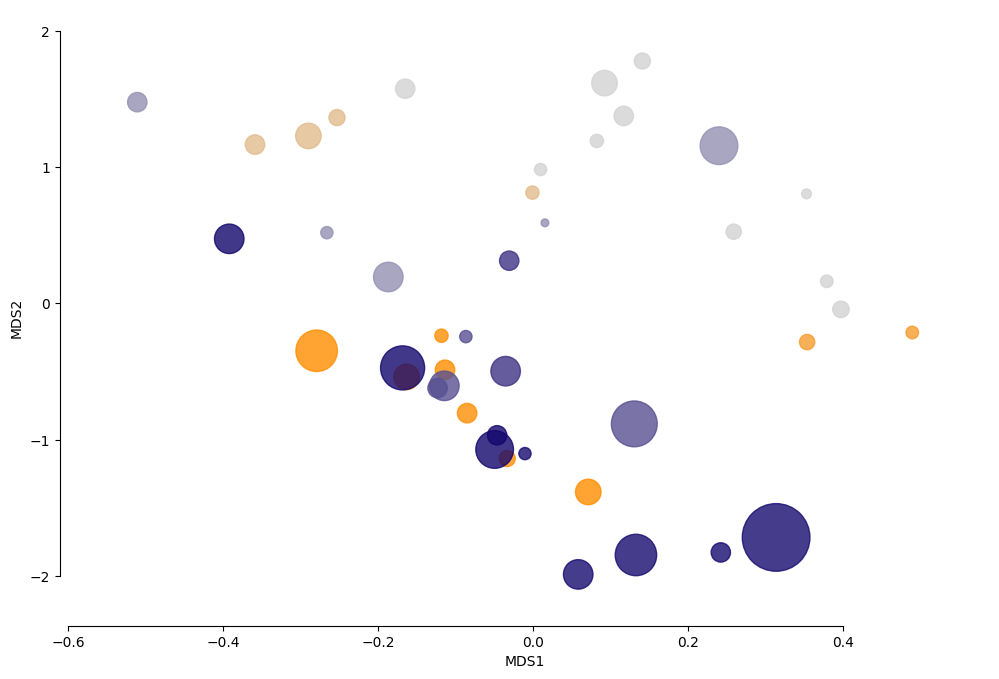

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import to_rgb, to_hex

fig, ax = plt.subplots(figsize=(12, 8))

palette = {
    'cnn': '#ff8d00',   # orange
    'vit': '#13066d',   # deep blue
}

backbones = merged["backbone"].unique()
marker_styles = ['o']

# Normalize training set size to [0, 1]
train_min, train_max = merged["train_set_size"].min(), merged["train_set_size"].max()


def blend_with_gray(color, factor, gray="#d3d3d3"):
    """Blend base color with gray based on factor ∈ [0,1].
       factor = 0 → original color; factor = 1 → gray."""
    base = np.array(to_rgb(color))
    gray_rgb = np.array(to_rgb(gray))
    blended = (1 - factor) * base + factor * gray_rgb
    return to_hex(blended)

for i, bb in enumerate(backbones):
    subset = merged[merged["backbone"] == bb]
    log_train = np.log10(subset["train_set_size"])
    log_min = np.log10(train_min)
    log_max = np.log10(train_max)
    norm_train_size = (log_train - log_min) / (log_max - log_min)

    colors = [blend_with_gray(palette[bb], 1 - t) for t in norm_train_size]
    # Compute blended colors toward grey
    colors = [blend_with_gray(palette[bb], 1 - t) for t in norm_train_size]

    plt.scatter(
        subset["MDS1"],
        subset["MDS2"],
        c=colors,
        s=subset["power_number_parameters"] / 1000,
        alpha=0.8,
        # marker=marker_styles[i % len(marker_styles)],
        label=bb
    )

plt.xlabel("MDS1")
plt.ylabel("MDS2")
# plt.legend(title="Backbone")
# plt.title("MDS of Models based on Performance Metrics")

ax.spines['left'].set_bounds(-2, 2)
ax.spines['bottom'].set_bounds(-0.6,0.4)
ax.tick_params(left=True, bottom=True)
sns.despine()
plt.margins(0.1)

plt.show()
plt.rcParams['svg.fonttype'] = 'none'
fig.savefig('figure_models_MDS.svg', format='svg')
